In [ ]:
# Install AerEO and any required plugins for this notebook (Google Colab)
!pip install -q "aereo[viz]"

# Step-by-step Sentinel-2 extraction 

This notebook runs the full AerEO pipeline — **Search**, **Build tasks** and **Extract (read and write)** — step by step. 

Each of these functions can be replaced by ANY function that conforms to the inputs and outputs of each step as follows:

| Step | Input | Output |
|------|-------|--------|
| Search | `(collections, intersects, start_datetime, end_datetime, **kwargs)` | `GeoDataFrame[AssetSchema]` |
| Build | `(GeoDataFrame[AssetSchema], ExtractionJob, **kwargs)` | `Sequence[ExtractionTask]` |
| Read | `(task: ExtractionTask, **kwargs)` | `xr.Dataset` |
| Write | `(ds: xr.Dataset, path: str, **kwargs)` | `str` |


## No YAML config

This notebook builds the `ExtractionJob` directly in Python, so there is no separate YAML config file to copy. The equivalent YAML config is shown in the [Sentinel-2 (nir, red)](01-sentinel2.ipynb) tutorial.


# Configuring AOI, Grid and Extraction pipeline
Before we start, we must configure our `ExtractionJob`. 
This means defining the `grid` to use, the aoi and the pipeline functions to use for each step.

If we know all of this beforehand, we can run our pipeline anywhere by serializing the job, and define different pipelines using only config files!





In [1]:
from aereo.builtins.search import search_stac
from datetime import datetime, timezone
from shapely.geometry import Polygon

from aereo.pipeline import ExtractionJob
from aereo.builtins import read_odc_stac, write_geotiff

# AOI polygon — Chocón reservoir, Argentina (inlined so the notebook has no file dependencies).
aoi_polygon = Polygon(
    [
        (-68.90986824592407, -39.23705421799603),
        (-68.65925870907353, -39.23705421799603),
        (-68.65925870907353, -39.41589522092947),
        (-68.90986824592407, -39.41589522092947),
        (-68.90986824592407, -39.23705421799603),
    ]
)

grid_dist = 10_000

job = ExtractionJob(
    name="sentinel2_sample",
    grid_dist=grid_dist,
    output_uri="/tmp/aereo_extraction",
    read=read_odc_stac,
    write=write_geotiff,
    target_aoi=aoi_polygon,
)

## Step 1 — Search: `search_stac`

The search provider queries the STAC API and returns a GeoDataFrame of matched assets. Each row corresponds to one requested asset (e.g. `red`, `nir`) from one STAC item. All parameters are passed explicitly.


In [2]:
assets = search_stac(
    stac_api_url="https://earth-search.aws.element84.com/v1",
    collections={"sentinel-2-l2a": ["red", "nir"]},
    intersects=aoi_polygon,
    start_datetime=datetime(2024, 1, 1, tzinfo=timezone.utc),
    end_datetime=datetime(2024, 1, 10, tzinfo=timezone.utc),
)

print(f"\u2713 Found {len(assets)} asset rows")
print("Columns:", list(assets.columns))
print("First rows:")
assets[["id", "collection", "channel_id", "crs", "href"]].head()

✓ Found 12 asset rows
Columns: ['id', 'collection', 'geometry', 'start_time', 'end_time', 'href', 'channel_id', 'crs', 'stac_item']
First rows:


,id,collection,channel_id,crs,href
0,S2A_19HDS_20240107_0_L2A_red,sentinel-2-l2a,red,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
1,S2A_19HDS_20240107_0_L2A_nir,sentinel-2-l2a,nir,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
2,S2A_19HES_20240107_0_L2A_red,sentinel-2-l2a,red,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
3,S2A_19HES_20240107_0_L2A_nir,sentinel-2-l2a,nir,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...
4,S2B_19HDS_20240105_0_L2A_red,sentinel-2-l2a,red,EPSG:32719,https://sentinel-cogs.s3.us-west-2.amazonaws.c...


## Step 2 — Build tasks: `build_grouped_tasks`

The task builder takes the search-result GeoDataFrame and the `ExtractionJob` and produces a list of `ExtractionTask` objects. Tasks are grouped by start time and native CRS, and chunked by `cells_per_task`.


In [3]:
from aereo.builtins.task_builder import build_grouped_tasks

tasks = build_grouped_tasks(
    search_results=assets,
    job=job,
)
print(f"\u2713 Built {len(tasks)} extraction task(s)")
for i, task in enumerate(tasks):
    print(f"Task {i}: {task}")

✓ Built 6 extraction task(s)
Task 0: ExtractionTask(id='sentinel2_sample_2024-01-02 14:33:47.691000_EPSG:32719_0', n_assets=2, n_grid_cells=10, read=True, write=True, output_uri='/tmp/aereo_extraction')
Task 1: ExtractionTask(id='sentinel2_sample_2024-01-02 14:33:51.276000_EPSG:32719_1', n_assets=2, n_grid_cells=4, read=True, write=True, output_uri='/tmp/aereo_extraction')
Task 2: ExtractionTask(id='sentinel2_sample_2024-01-05 14:43:42.172000_EPSG:32719_2', n_assets=2, n_grid_cells=10, read=True, write=True, output_uri='/tmp/aereo_extraction')
Task 3: ExtractionTask(id='sentinel2_sample_2024-01-05 14:43:46.672000_EPSG:32719_3', n_assets=2, n_grid_cells=4, read=True, write=True, output_uri='/tmp/aereo_extraction')
Task 4: ExtractionTask(id='sentinel2_sample_2024-01-07 14:33:42.975000_EPSG:32719_4', n_assets=2, n_grid_cells=10, read=True, write=True, output_uri='/tmp/aereo_extraction')
Task 5: ExtractionTask(id='sentinel2_sample_2024-01-07 14:33:46.552000_EPSG:32719_5', n_assets=2, n_gri

In [4]:
# Inspect the first task in detail
task = tasks[0]

print("Grid cells:", task.grid_cells)
print("Task context:", dict(task.task_context))
print(f"Number of asset rows in task: {len(task.assets)}")

# Extraction stages available on the task (delegated from the job)
print("Extraction stages:")
print("  read callable:", callable(task.job.read))
print("  write callable:", callable(task.job.write))

Grid cells: [GridCell(id='439D_593L', d=10000, cell_geometry=<POLYGON ((-68.837 -39.431, -68.837 -39.341, -68.953 -39.341, -68.953 -39.43...>), GridCell(id='439D_592L', d=10000, cell_geometry=<POLYGON ((-68.721 -39.431, -68.721 -39.341, -68.837 -39.341, -68.837 -39.43...>), GridCell(id='439D_591L', d=10000, cell_geometry=<POLYGON ((-68.605 -39.431, -68.605 -39.341, -68.721 -39.341, -68.721 -39.43...>), GridCell(id='438D_594L', d=10000, cell_geometry=<POLYGON ((-68.865 -39.341, -68.865 -39.251, -68.981 -39.251, -68.981 -39.34...>), GridCell(id='438D_593L', d=10000, cell_geometry=<POLYGON ((-68.748 -39.341, -68.748 -39.251, -68.865 -39.251, -68.865 -39.34...>), GridCell(id='438D_592L', d=10000, cell_geometry=<POLYGON ((-68.632 -39.341, -68.632 -39.251, -68.748 -39.251, -68.748 -39.34...>), GridCell(id='437D_595L', d=10000, cell_geometry=<POLYGON ((-68.892 -39.251, -68.892 -39.162, -69.008 -39.162, -69.008 -39.25...>), GridCell(id='437D_594L', d=10000, cell_geometry=<POLYGON ((-68.776 -39

## Step 3 — Read: `read_odc_stac`

The reader reconstructs `pystac.Item` objects from the asset table and uses `odc.stac.load` to build a lazy `xarray.Dataset` in the native CRS of the STAC items.


In [5]:
ds_native = job.read(task)

print("Native dataset:")
ds_native
# ds_native["red"].plot()

Native dataset:


<xarray.Dataset> Size: 48MB
Dimensions:      (y: 3002, x: 4009)
Coordinates:
  * y            (y) float64 24kB 5.665e+06 5.665e+06 ... 5.635e+06 5.635e+06
  * x            (x) float64 32kB 4.993e+05 4.993e+05 ... 5.394e+05 5.394e+05
    spatial_ref  int32 4B 32719
Data variables:
    red          (y, x) uint16 24MB dask.array<chunksize=(3002, 4009), meta=np.ndarray>
    nir          (y, x) uint16 24MB dask.array<chunksize=(3002, 4009), meta=np.ndarray>
Attributes:
    start_time:  2024-01-02 14:33:47.691000
    end_time:    2024-01-02 14:33:47.691000

## Step 4 — Write: `write_geotiff`

The writer serialises a dataset to a GeoTIFF at the path supplied by the caller and returns the written path.


In [6]:
from pathlib import Path

# Write the native dataset to a temporary path
out_path = Path(job.output_uri) / "demo_native_red.tif"
# crate the parent directory if it doesn't exist
out_path.parent.mkdir(parents=True, exist_ok=True)
written = job.write(ds=ds_native, path=out_path)

print(f"\u2713 Wrote {written}")

✓ Wrote /tmp/aereo_extraction/demo_native_red.tif


## Batch execution with an executor

To run many tasks in parallel, pass the task list to an `Executor`. For COG/IO-bound extractors like this one, `LocalExecutor(use_threads=True)` is the safer choice in Jupyter and avoids the pickling issues that can make `ProcessPoolExecutor` hang.

#### Partial functions
Because the executor calls the `read` and `write` functions for each task in this case, it is important that, if extra params are needed, these functions are passed as partial functions. This is done in the `ExtractionJob` constructor, and the executor simply calls them with the task as the only argument. Usually, this is done automatically by Hydra when the job is constructed from a config file, but it can also be done manually as shown below.


In [7]:
from aereo.executors import LocalExecutor

# set job with partial functions for read and write
from functools import partial

# create a write partial function passing rioxarray/to_raster kwargs
write_partial = partial(write_geotiff, compress="LZW", tags={"creator": "aereo"})

job = ExtractionJob(
    name="sentinel2_sample",
    grid_dist=grid_dist,
    output_uri="/tmp/aereo_extraction",
    read=read_odc_stac,
    write=write_partial,
    target_aoi=aoi_polygon,
)

# lets build again the tasks with the new job
tasks = build_grouped_tasks(
    search_results=assets,
    job=job,
)

executor = LocalExecutor(workers=4, use_threads=True)
artifacts = executor(tasks)

print(f"\u2713 Extracted {len(artifacts)} artifact row(s) from {len(tasks)} task(s)")
artifacts[["id", "uri", "grid_cell", "start_time"]].head()

✓ Extracted 42 artifact row(s) from 6 task(s)


,id,uri,grid_cell,start_time
0,439D_593L_7673608a,/tmp/aereo_extraction/job-sentinel2_sample/dat...,439D_593L,2024-01-02 14:33:47.691
1,439D_592L_08f5ddb0,/tmp/aereo_extraction/job-sentinel2_sample/dat...,439D_592L,2024-01-02 14:33:47.691
2,439D_591L_9b2a68a9,/tmp/aereo_extraction/job-sentinel2_sample/dat...,439D_591L,2024-01-02 14:33:47.691
3,438D_594L_05747684,/tmp/aereo_extraction/job-sentinel2_sample/dat...,438D_594L,2024-01-02 14:33:47.691
4,438D_593L_ea66a297,/tmp/aereo_extraction/job-sentinel2_sample/dat...,438D_593L,2024-01-02 14:33:47.691


In [8]:
# lets check that chunks are ok
import rioxarray

rioxarray.open_rasterio(artifacts["uri"].iloc[0])

<xarray.DataArray (band: 2, y: 3002, x: 4009)> Size: 48MB
[24070036 values with dtype=uint16]
Coordinates:
  * band         (band) int64 16B 1 2
  * y            (y) float64 24kB 5.665e+06 5.665e+06 ... 5.635e+06 5.635e+06
  * x            (x) float64 32kB 4.993e+05 4.993e+05 ... 5.394e+05 5.394e+05
    spatial_ref  int64 8B 0
Attributes:
    creator:        aereo
    end_time:       2024-01-02 14:33:47.691000
    start_time:     2024-01-02 14:33:47.691000
    AREA_OR_POINT:  Area
    _FillValue:     0
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      ('red', 'nir')

(<Figure size 2000x1495.93 with 2 Axes>,
 <Axes: title={'center': 'Extracted Patches Spatial Overview'}, xlabel='UTM X', ylabel='UTM Y'>)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


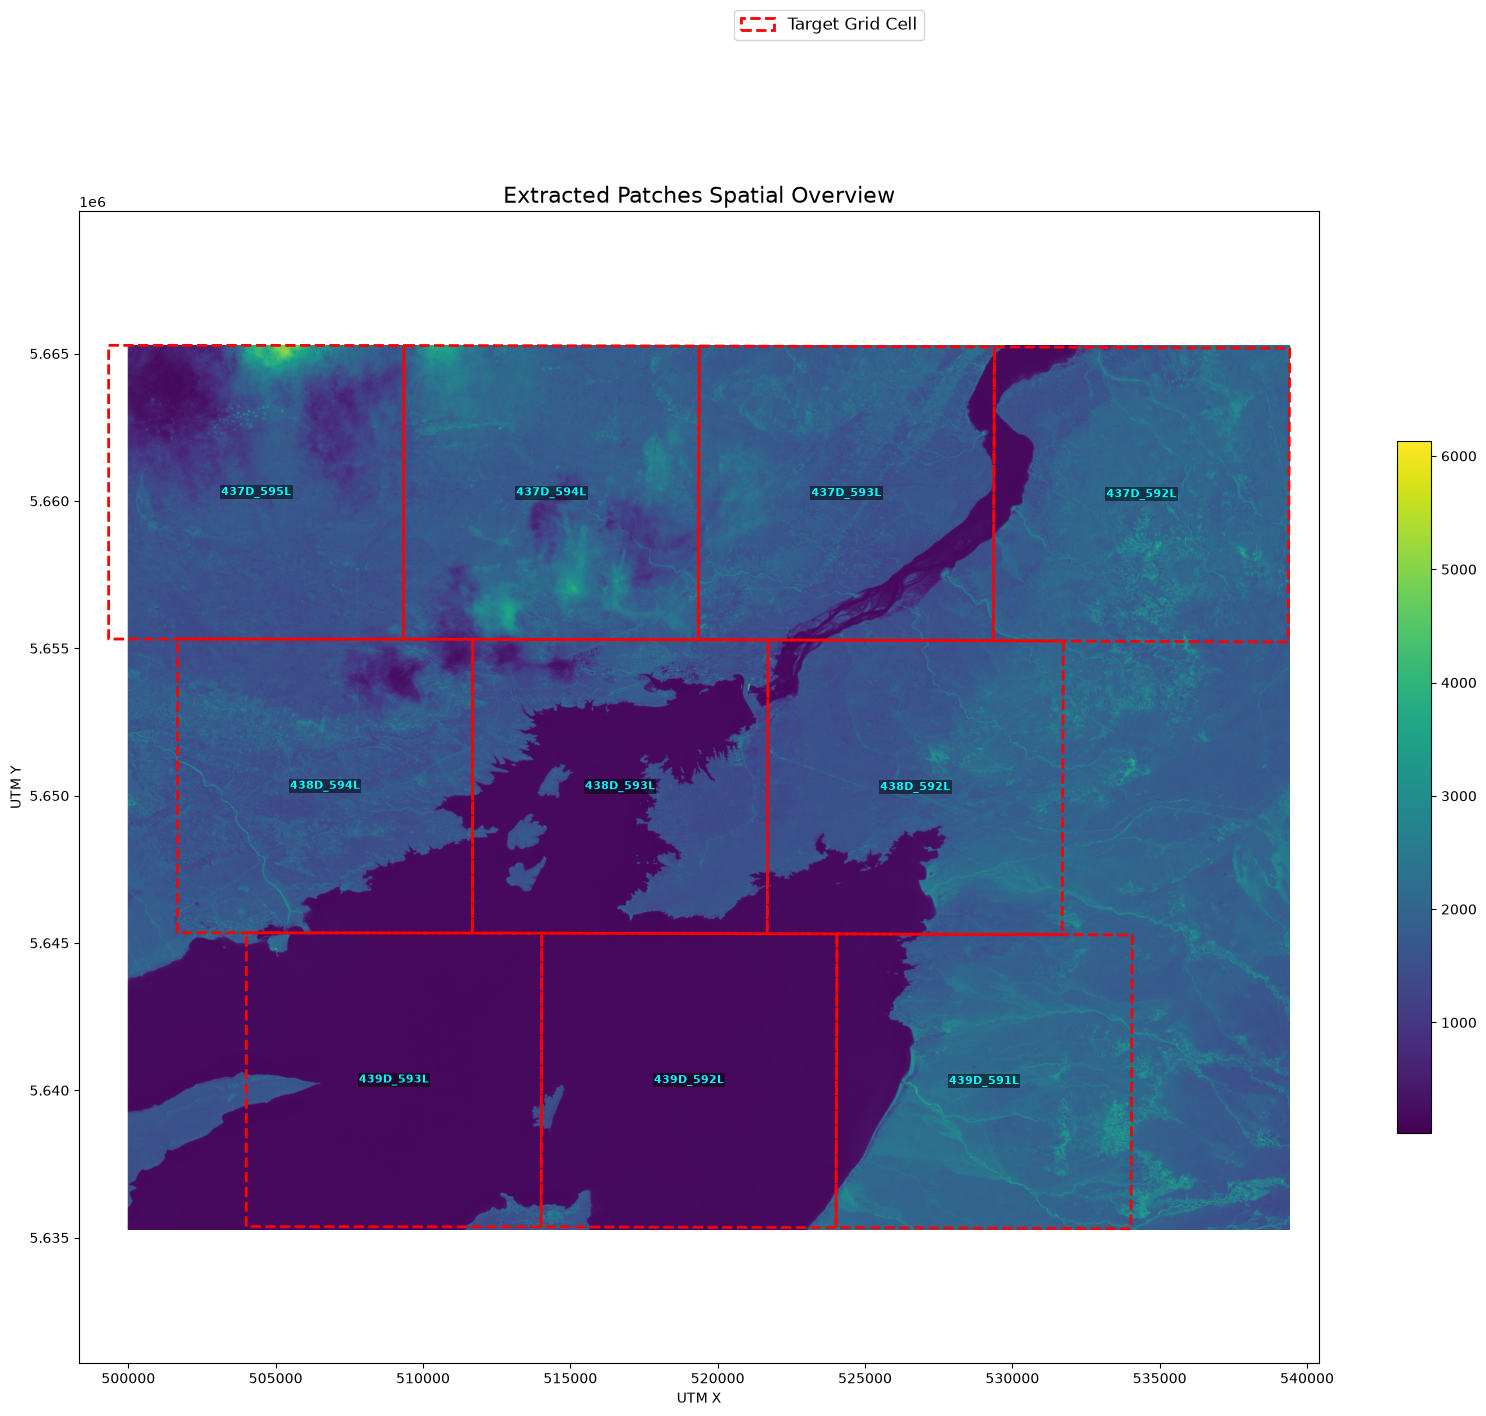

In [9]:
from aereo.viz import plot_artifact_patches

plot_artifact_patches(artifacts, ds_factor=1, cmap="viridis")